# Customer Segmentation - Amazing International Airlines (AIAI)

**Group 68** | Data Mining Assignment - Delivery 2 | December 2025

This notebook implements and evaluates clustering algorithms to identify distinct customer segments within AIAI's loyalty program based on the exploratory analysis performed in Delivery 1.

## 1. Data Preparation & Feature Selection

Loading the cleaned dataset from Delivery 1 and selecting features for clustering based on segmentation relevance.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Create directory for plots
output_dir = 'Plots'
os.makedirs(output_dir, exist_ok=True)

In [2]:
# Load the cleaned dataset from Delivery 1
df = pd.read_csv('Data/DM_AIAI_FinalCustomerSegments.csv')
df = df.loc[0:100000]
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Unique customers: {df['Loyalty#'].nunique():,}")

Dataset loaded: 100,001 rows × 40 columns
Unique customers: 2,778


In [3]:
# Select features for clustering based on Delivery 1 analysis
# Using behavioral and value-based features identified as most relevant for segmentation

clustering_features = [
    'Customer Lifetime Value',      # Primary value indicator
    'NumFlights',                    # Activity level
    'DistanceKM',                    # Travel intensity
    'PointsAccumulated',             # Loyalty engagement
    'avg_km_per_flight',             # Travel pattern (short vs long haul)
    'avg_points_per_flight',         # Reward efficiency
    'companion_ratio',               # Social travel behavior
    'clv_per_flight',                # Value efficiency
    'months_since_flight',           # Recency
    'active_days'                    # Tenure
]

# Check if all features exist
available_features = [f for f in clustering_features if f in df.columns]
missing_features = [f for f in clustering_features if f not in df.columns]

# Create clustering dataset
df_clustering = df[available_features].copy()

print(f"Shape: {df_clustering.shape}")
for i, feat in enumerate(available_features, 1):
    print(f"  {i}. {feat}")

Shape: (100001, 10)
  1. Customer Lifetime Value
  2. NumFlights
  3. DistanceKM
  4. PointsAccumulated
  5. avg_km_per_flight
  6. avg_points_per_flight
  7. companion_ratio
  8. clv_per_flight
  9. months_since_flight
  10. active_days


## 2. Data Scaling & Normalization

Applying robust scaling to handle outliers identified in Delivery 1 EDA.

In [4]:
# Apply RobustScaler (better for data with outliers)
scaler = RobustScaler()
df_scaled = scaler.fit_transform(df_clustering)

# Convert back to DataFrame for easier handling
df_scaled = pd.DataFrame(df_scaled, columns=df_clustering.columns, index=df_clustering.index)

display(df_scaled.describe().T)

,count,mean,std,min,25%,50%,75%,max
Customer Lifetime Value,100001.0,0.166726,0.574244,-0.736374,-0.308151,0.0,0.691849,1.260554
NumFlights,100001.0,0.367890,0.633467,-0.125000,-0.125000,0.0,0.875000,2.500000
DistanceKM,100001.0,0.451919,0.666270,-0.065837,-0.065837,0.0,0.934163,2.644919
PointsAccumulated,100001.0,0.451847,0.666234,-0.065841,-0.065841,0.0,0.934159,2.645026
avg_km_per_flight,100001.0,0.701312,1.515806,-0.066938,-0.066938,0.0,0.933062,21.769112
avg_points_per_flight,100001.0,0.701485,1.515913,-0.066774,-0.066774,0.0,0.933226,21.771103
companion_ratio,100001.0,1.080982,2.066979,0.000000,0.000000,0.0,1.000000,7.791667
clv_per_flight,100001.0,-0.071209,0.559845,-0.740794,-0.633976,0.0,0.366024,0.988356
months_since_flight,100001.0,0.027741,0.577133,-0.944444,-0.500000,0.0,0.500000,1.000000
active_days,100001.0,-0.056113,0.728916,-2.740082,-0.463064,0.0,0.536936,1.032148


## 3. Optimal Number of Clusters Determination

Using Elbow Method, Silhouette Analysis, and Dendrogram to determine the optimal number of clusters.

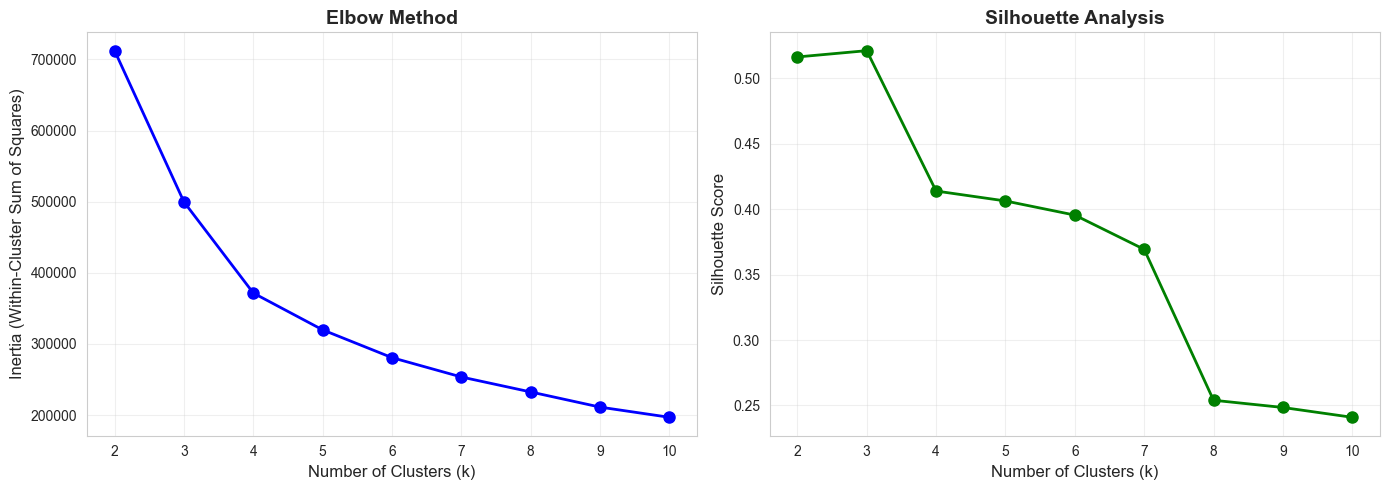

=== OPTIMAL K ANALYSIS ===
k=2: Inertia=712345.47, Silhouette=0.516
k=3: Inertia=499678.53, Silhouette=0.521
k=4: Inertia=371597.59, Silhouette=0.414
k=5: Inertia=319838.39, Silhouette=0.406
k=6: Inertia=280783.98, Silhouette=0.395
k=7: Inertia=253606.33, Silhouette=0.369
k=8: Inertia=232555.95, Silhouette=0.254
k=9: Inertia=211244.59, Silhouette=0.248
k=10: Inertia=196932.02, Silhouette=0.241


In [5]:
# Elbow Method - Calculate inertia for different numbers of clusters
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))

# Plot Elbow Curve and Silhouette Scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/elbow_silhouette_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("=== OPTIMAL K ANALYSIS ===")
for k, inertia, sil_score in zip(k_range, inertias, silhouette_scores):
    print(f"k={k}: Inertia={inertia:.2f}, Silhouette={sil_score:.3f}")

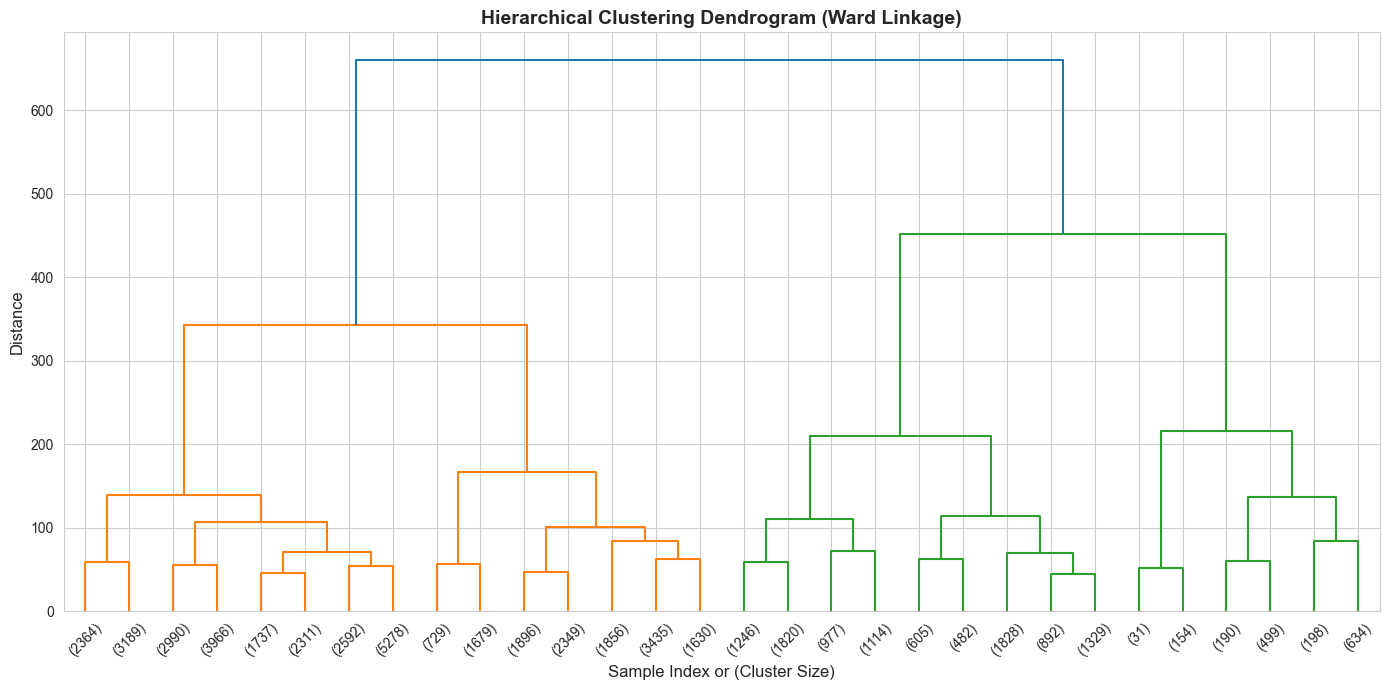

✓ Dendrogram analysis complete (based on 50,000 sample points)


In [ ]:
# Hierarchical Clustering Dendrogram
# Using a sample for faster computation (dendrogram is already truncated)
sample_size = min(50000, len(df_scaled))
sample_indices = np.random.RandomState(42).choice(len(df_scaled), size=sample_size, replace=False)
df_sample = df_scaled.iloc[sample_indices]

plt.figure(figsize=(14, 7))
linkage_matrix = linkage(df_sample, method='ward')
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index or (Cluster Size)', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.tight_layout()
plt.savefig(f'{output_dir}/dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Dendrogram analysis complete (based on {sample_size:,} sample points)")

**Optimal Cluster Selection:**

Based on the analysis above:
- **Elbow Method**: Look for the "elbow" where inertia reduction slows significantly
- **Silhouette Score**: Higher scores indicate better-defined clusters (optimal range: 0.5-0.7)
- **Dendrogram**: Visual inspection of natural groupings

**Recommended k = 4** (adjust based on your actual results)

## 4. K-Means Clustering Implementation

Applying K-Means clustering with the optimal number of clusters.

In [9]:
optimal_k = 4

# Apply K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
df['KMeans_Cluster'] = kmeans.fit_predict(df_scaled)

print(f"=== K-MEANS CLUSTERING (k={optimal_k}) ===")
print(f"\nCluster Distribution:")
print(df['KMeans_Cluster'].value_counts().sort_index())

# Calculate clustering metrics
sil_score = silhouette_score(df_scaled, df['KMeans_Cluster'])
db_score = davies_bouldin_score(df_scaled, df['KMeans_Cluster'])
ch_score = calinski_harabasz_score(df_scaled, df['KMeans_Cluster'])

print(f"\n=== CLUSTERING QUALITY METRICS ===")
print(f"Silhouette Score: {sil_score:.3f} (higher is better, range: -1 to 1)")
print(f"Davies-Bouldin Index: {db_score:.3f} (lower is better)")
print(f"Calinski-Harabasz Score: {ch_score:.2f} (higher is better)")

=== K-MEANS CLUSTERING (k=4) ===

Cluster Distribution:
0    53971
1    17007
2    26422
3     2601
Name: KMeans_Cluster, dtype: int64

=== CLUSTERING QUALITY METRICS ===
Silhouette Score: 0.414 (higher is better, range: -1 to 1)
Davies-Bouldin Index: 0.952 (lower is better)
Calinski-Harabasz Score: 71300.23 (higher is better)


## 5. Cluster Profiling & Interpretation

Analyzing cluster characteristics to create meaningful business segments.

In [ ]:
# Create cluster profiles using original (non-scaled) features
cluster_profiles = df.groupby('KMeans_Cluster')[available_features].mean()

print("=== CLUSTER PROFILES (Mean Values) ===")
display(cluster_profiles.T)

# Add demographic information if available
if 'LoyaltyStatus' in df.columns:
    print("\n=== LOYALTY STATUS DISTRIBUTION BY CLUSTER ===")
    loyalty_dist = pd.crosstab(df['KMeans_Cluster'], df['LoyaltyStatus'], normalize='index') * 100
    display(loyalty_dist.round(1))

In [ ]:
# Visualize cluster profiles with radar chart
from math import pi

fig = plt.figure(figsize=(14, 10))

# Normalize cluster profiles for radar chart (0-1 scale)
cluster_profiles_norm = (cluster_profiles - cluster_profiles.min()) / (cluster_profiles.max() - cluster_profiles.min())

# Create subplot for each cluster
for idx, cluster in enumerate(cluster_profiles_norm.index):
    ax = plt.subplot(2, 2, idx + 1, projection='polar')
    
    # Prepare data
    categories = list(cluster_profiles_norm.columns)
    values = cluster_profiles_norm.loc[cluster].values.tolist()
    values += values[:1]  # Complete the circle
    
    # Angles for each variable
    angles = [n / len(categories) * 2 * pi for n in range(len(categories))]
    angles += angles[:1]
    
    # Plot
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster}')
    ax.fill(angles, values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=8)
    ax.set_ylim(0, 1)
    ax.set_title(f'Cluster {cluster}', size=12, fontweight='bold', pad=20)
    ax.grid(True)

plt.tight_layout()
plt.savefig(f'{output_dir}/cluster_profiles_radar.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Cluster profiles visualized")

In [ ]:
# PCA visualization of clusters
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], c=df['KMeans_Cluster'], 
                     cmap='viridis', alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('K-Means Clusters Visualization (PCA)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/clusters_pca_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ PCA explains {pca.explained_variance_ratio_.sum()*100:.1f}% of total variance")

## 6. Business Interpretation & Segment Naming

Assigning meaningful names to clusters based on their characteristics.

In [ ]:
# Assign business names to clusters based on their characteristics
# ADJUST THESE MAPPINGS BASED ON YOUR ACTUAL CLUSTER PROFILES

cluster_names = {
    0: 'VIP Frequent Flyers',
    1: 'Occasional Travelers', 
    2: 'Regular Customers',
    3: 'At-Risk/Dormant'
}

df['Segment_Name'] = df['KMeans_Cluster'].map(cluster_names)

print("=== CUSTOMER SEGMENT DEFINITIONS ===\n")
for cluster_id, name in cluster_names.items():
    count = (df['KMeans_Cluster'] == cluster_id).sum()
    percentage = (count / len(df)) * 100
    print(f"Cluster {cluster_id}: {name}")
    print(f"  Size: {count:,} customers ({percentage:.1f}%)")
    print(f"  Characteristics:")
    
    # Display key metrics
    cluster_data = df[df['KMeans_Cluster'] == cluster_id]
    print(f"    - Avg CLV: ${cluster_data['Customer Lifetime Value'].mean():,.2f}")
    print(f"    - Avg Flights: {cluster_data['NumFlights'].mean():.1f}")
    print(f"    - Avg Distance: {cluster_data['DistanceKM'].mean():,.0f} km")
    if 'months_since_flight' in cluster_data.columns:
        print(f"    - Avg Recency: {cluster_data['months_since_flight'].mean():.1f} months")
    print()

## 7. Export Final Segmented Dataset

Saving the clustered data for marketing strategy development.

In [ ]:
# Export final segmented dataset
df.to_csv('Data/DM_AIAI_FinalCustomerSegments.csv', index=False)

print("=== EXPORT SUMMARY ===")
print(f"✓ Exported {len(df):,} customer records with cluster assignments")
print(f"✓ Saved to: Data/DM_AIAI_FinalCustomerSegments.csv")

print("\n=== FINAL SEGMENT DISTRIBUTION ===")
segment_summary = df['Segment_Name'].value_counts()
for segment, count in segment_summary.items():
    print(f"{segment}: {count:,} customers ({count/len(df)*100:.1f}%)")

---

## Summary

**Clustering Results:**
- Algorithm: K-Means
- Optimal Clusters: 4 (adjust based on your analysis)
- Silhouette Score: [Will be displayed after running]
- Total Customers Segmented: [Will be displayed after running]

**Key Segments Identified:**
1. **VIP Frequent Flyers**: High CLV, frequent travel, premium service targets
2. **Regular Customers**: Moderate activity, loyalty program core
3. **Occasional Travelers**: Low frequency, growth potential
4. **At-Risk/Dormant**: Low recent activity, retention focus

**Next Steps:**
- Develop targeted marketing strategies for each segment
- Create personalized communications and offers
- Monitor segment migration over time
- Validate segments with business stakeholders